## PHASE 1: Data Loading & Preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings 
warnings.filterwarnings("ignore")
import plotly.express as px

In [2]:
df = pd.read_csv('Amazon.csv')
df.head()

,date,open,high,low,close,adj_close,volume
0,1997-05-15 00:00:00-04:00,0.121875,0.125000,0.096354,0.097917,0.097917,1443120000
1,1997-05-16 00:00:00-04:00,0.098438,0.098958,0.085417,0.086458,0.086458,294000000
2,1997-05-19 00:00:00-04:00,0.088021,0.088542,0.081250,0.085417,0.085417,122136000
3,1997-05-20 00:00:00-04:00,0.086458,0.087500,0.081771,0.081771,0.081771,109344000
4,1997-05-21 00:00:00-04:00,0.081771,0.082292,0.068750,0.071354,0.071354,377064000


In [3]:
df['date'] = pd.to_datetime(df['date'], utc=True)

df = df.sort_values('date')

df.set_index('date', inplace=True)

df.index

DatetimeIndex(['1997-05-15 04:00:00+00:00', '1997-05-16 04:00:00+00:00',
               '1997-05-19 04:00:00+00:00', '1997-05-20 04:00:00+00:00',
               '1997-05-21 04:00:00+00:00', '1997-05-22 04:00:00+00:00',
               '1997-05-23 04:00:00+00:00', '1997-05-27 04:00:00+00:00',
               '1997-05-28 04:00:00+00:00', '1997-05-29 04:00:00+00:00',
               ...
               '2025-02-06 05:00:00+00:00', '2025-02-07 05:00:00+00:00',
               '2025-02-10 05:00:00+00:00', '2025-02-11 05:00:00+00:00',
               '2025-02-12 05:00:00+00:00', '2025-02-13 05:00:00+00:00',
               '2025-02-14 05:00:00+00:00', '2025-02-18 05:00:00+00:00',
               '2025-02-19 05:00:00+00:00', '2025-02-20 05:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='date', length=6986, freq=None)

## PHASE 2: Data Overview & Summary Statistics

In [4]:
df.shape

(6986, 6)

In [5]:
df.isnull().sum()

open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6986 entries, 1997-05-15 04:00:00+00:00 to 2025-02-20 05:00:00+00:00
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   open       6986 non-null   float64
 1   high       6986 non-null   float64
 2   low        6986 non-null   float64
 3   close      6986 non-null   float64
 4   adj_close  6986 non-null   float64
 5   volume     6986 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 382.0 KB


In [9]:
df.describe()

,open,high,low,close,adj_close,volume
count,6986.000000,6986.000000,6986.000000,6986.000000,6986.000000,6.986000e+03
mean,40.666560,41.139546,40.153303,40.659883,40.659883,1.360668e+08
std,58.107283,58.751435,57.401423,58.091213,58.091213,1.375800e+08
min,0.070313,0.072396,0.065625,0.069792,0.069792,9.744000e+06
25%,2.100125,2.148125,2.064125,2.109750,2.109750,6.300350e+07
50%,9.033250,9.158500,8.921750,9.017000,9.017000,1.005360e+08
75%,72.673750,73.596622,71.368876,72.900251,72.900251,1.555295e+08
max,239.020004,242.520004,238.029999,242.059998,242.059998,2.086584e+09


## PHASE 3: Trend Analysis

Text(0, 0.5, 'closing Price')

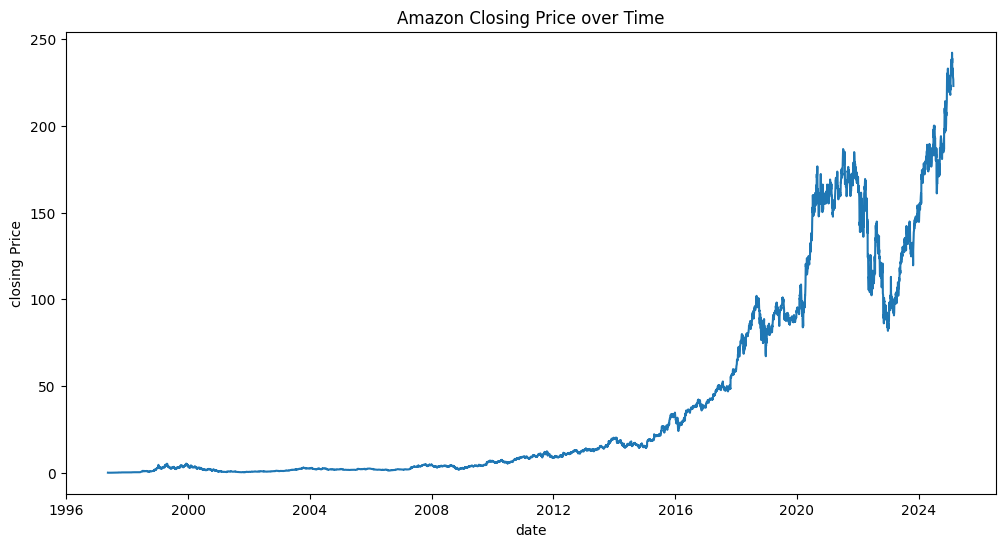

In [10]:
plt.figure(figsize=(12,6))
plt.plot(df['close'])
plt.title("Amazon Closing Price over Time")
plt.xlabel('date')
plt.ylabel('closing Price')

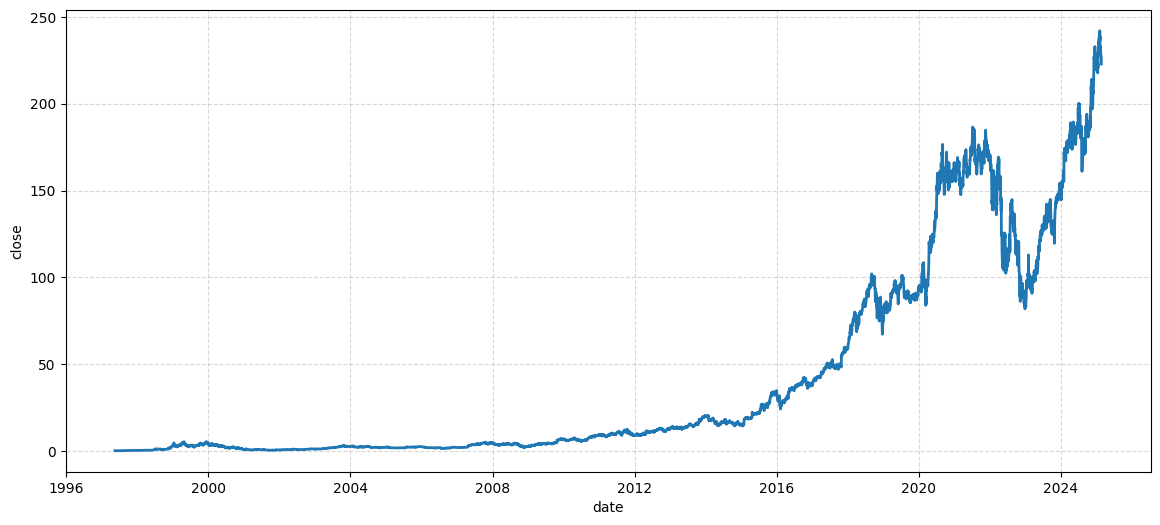

In [11]:
plt.figure(figsize=(14,6))

sns.lineplot(x=df.index, y=df['close'], linewidth=2)
plt.grid(True, linestyle='--', alpha=0.5)


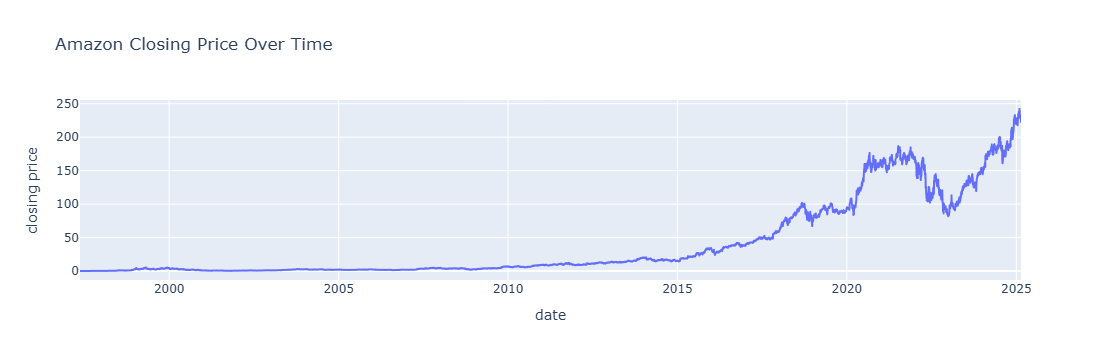

In [12]:
fig = px.line(df ,x=df.index, y='close', title="Amazon Closing Price Over Time",labels={'close' : 'closing price'},hover_data=['open','high','low','volume'])
fig.show()

In [13]:
total_growth = ((df['close'].iloc[-1] - df['close'].iloc[0])/df['close'].iloc[0])*100
print("Total Growth %:", total_growth)

Total Growth %: 227521.36248604412


## PHASE 4: Daily Returns & Volatility

In [14]:
df['daily_return'] = df['close'].pct_change()
df['daily_return'].head()

date
1997-05-15 04:00:00+00:00         NaN
1997-05-16 04:00:00+00:00   -0.117028
1997-05-19 04:00:00+00:00   -0.012040
1997-05-20 04:00:00+00:00   -0.042685
1997-05-21 04:00:00+00:00   -0.127392
Name: daily_return, dtype: float64

In [15]:
df['daily_return'].describe()

count    6985.000000
mean        0.001714
std         0.035176
min        -0.247661
25%        -0.012919
50%         0.000423
75%         0.014644
max         0.344714
Name: daily_return, dtype: float64

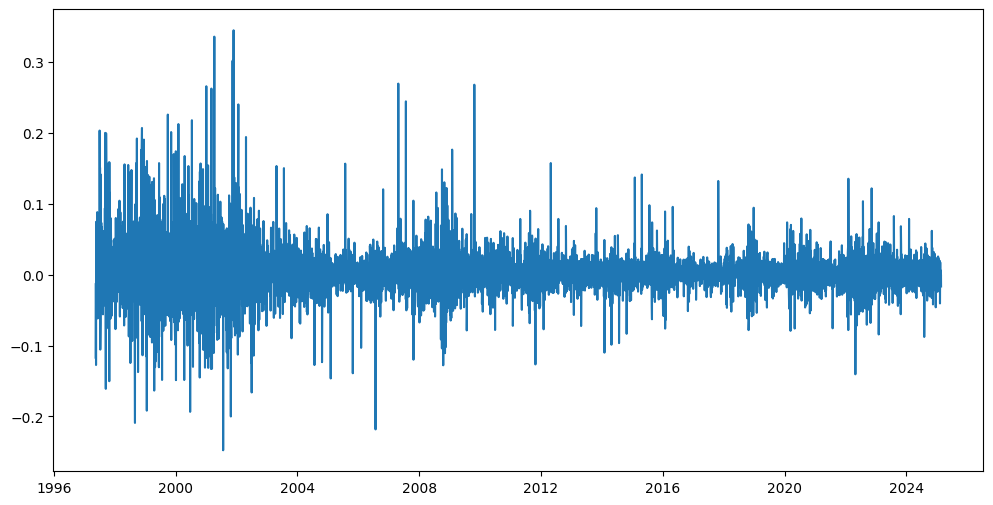

In [16]:
plt.figure(figsize=(12,6))
plt.plot(df['daily_return'])

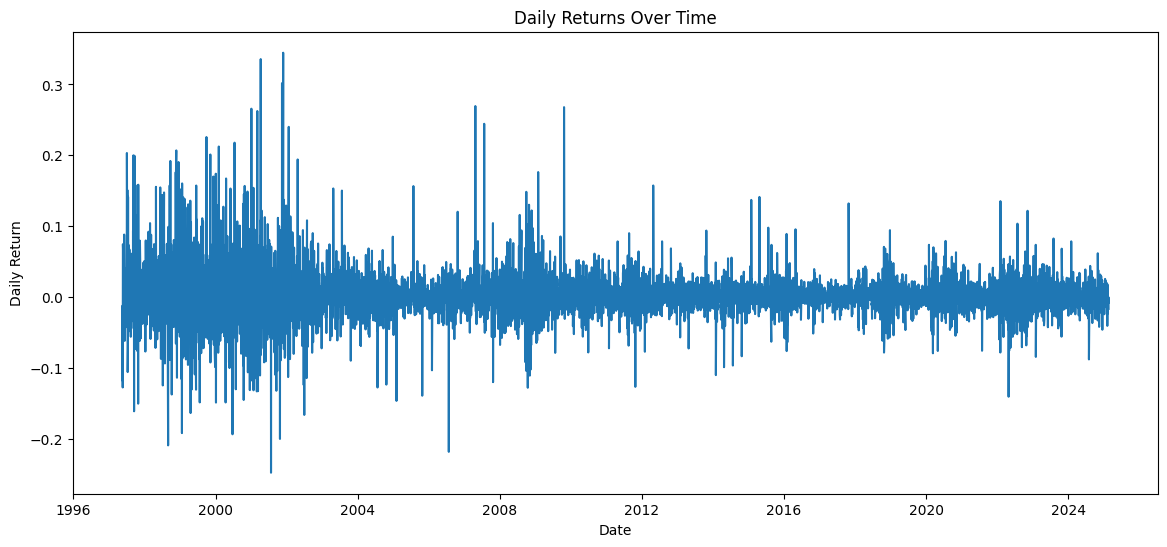

In [17]:
plt.figure(figsize=(14,6))
sns.lineplot(x=df.index, y=df['daily_return'])
plt.title("Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

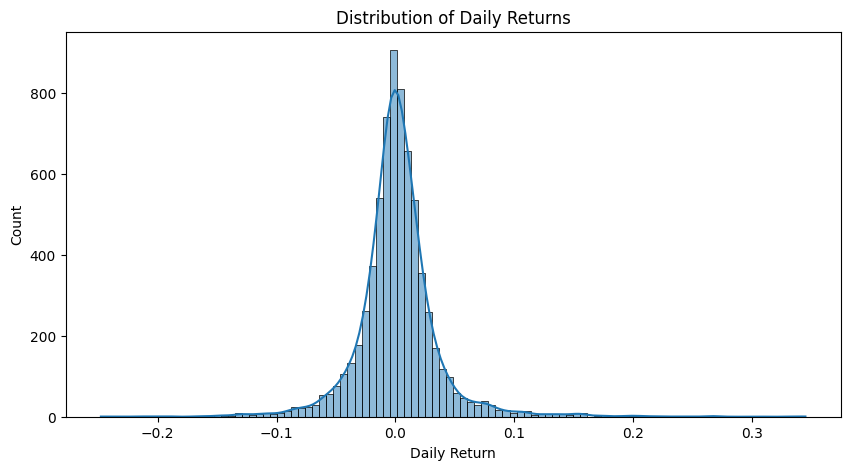

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(df['daily_return'], bins=100, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()

In [19]:
volatility = df['daily_return'].std()

print(f"Daily Volatility: {volatility:.4f}")

Daily Volatility: 0.0352


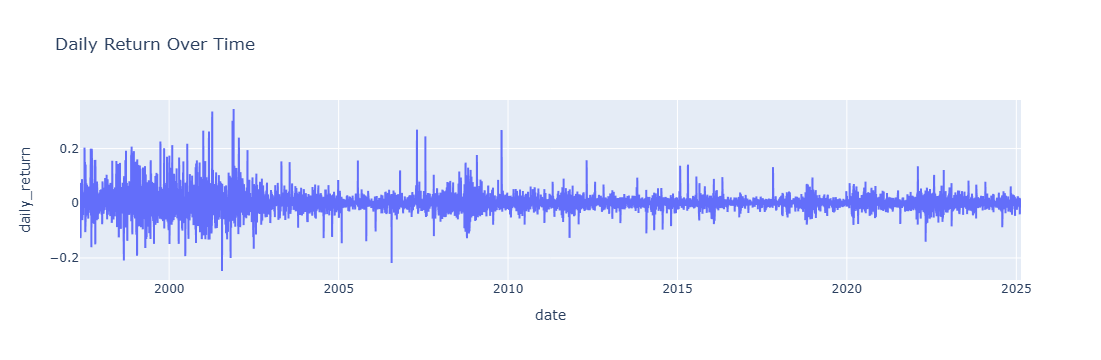

In [20]:
px.line(df,x= df.index,y= 'daily_return',title='Daily Return Over Time')

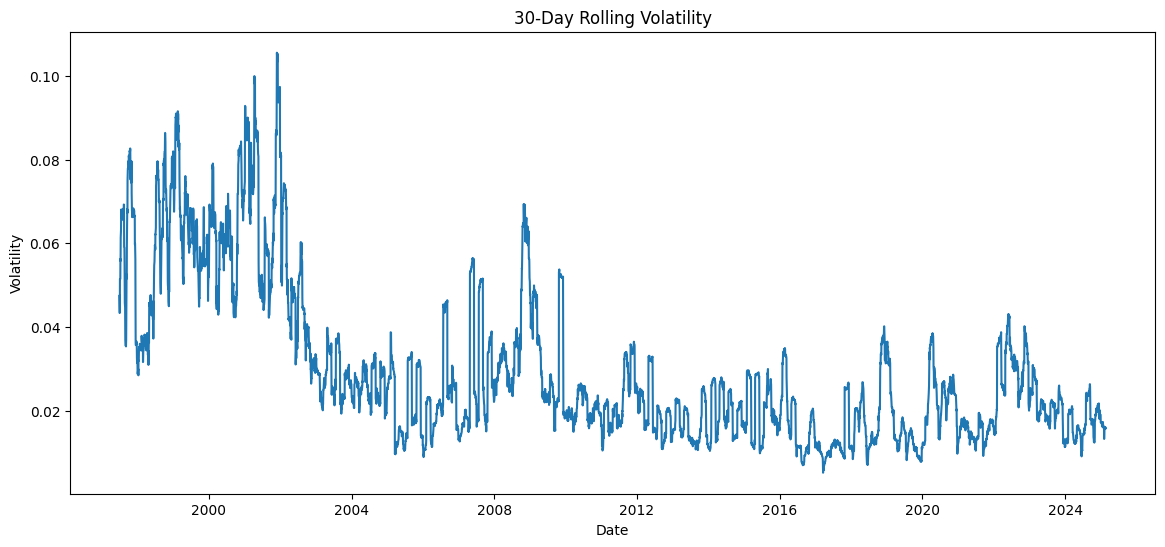

In [21]:
df['rolling_volatility'] = df['daily_return'].rolling(30).std()

plt.figure(figsize=(14,6))
sns.lineplot(x=df.index, y=df['rolling_volatility'])
plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

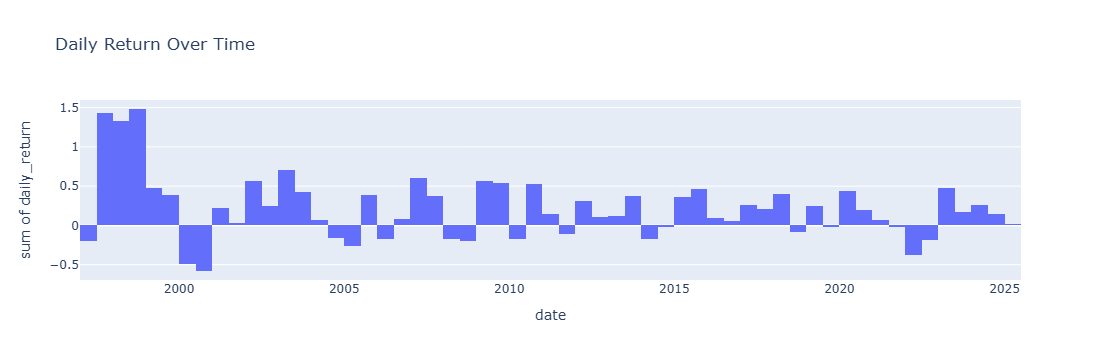

In [22]:
px.histogram(df,x= df.index,y= 'daily_return',title='Daily Return Over Time')

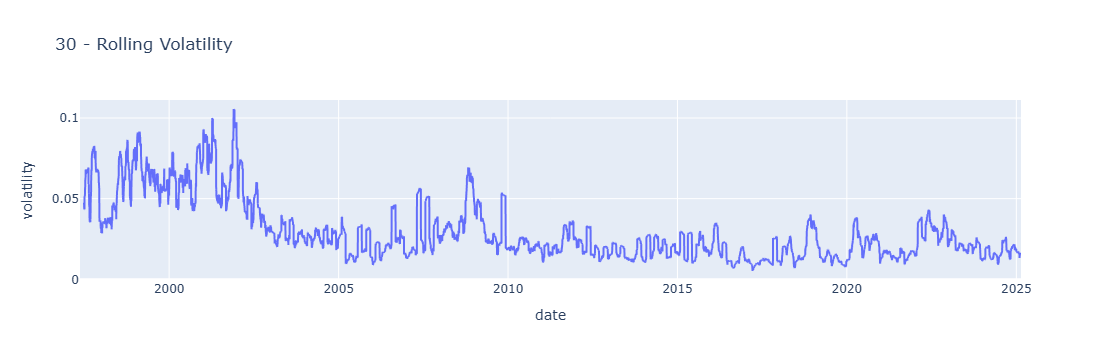

In [23]:
px.line(df,x= df.index,y= 'rolling_volatility',title='30 - Rolling Volatility',
       labels={'rolling_volatility': 'volatility'})

## PHASE 5: Volume Analysis

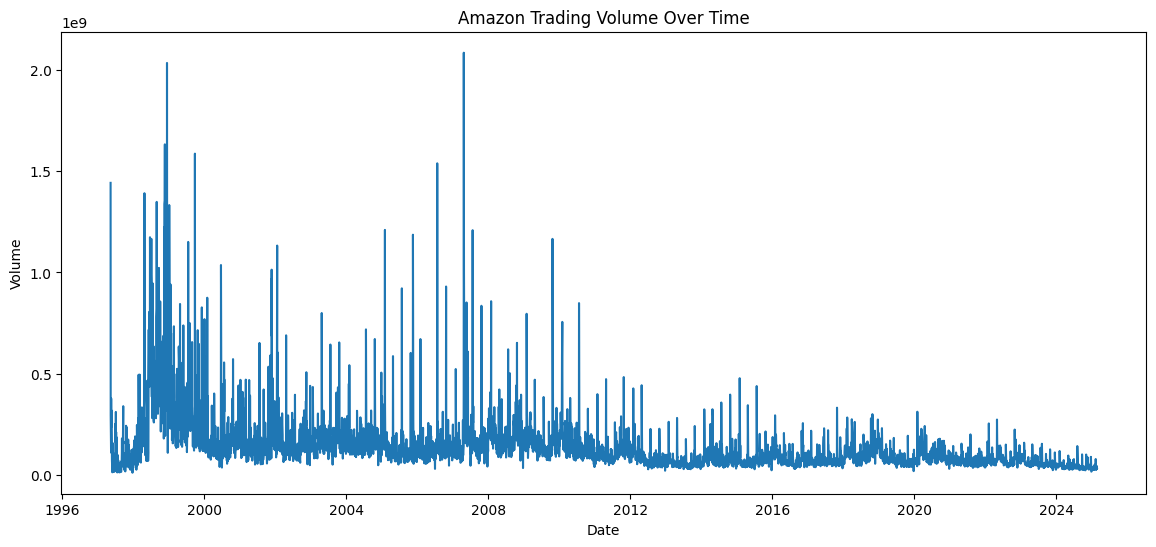

In [24]:
plt.figure(figsize=(14,6))

sns.lineplot(x=df.index, y=df['volume'])

plt.title("Amazon Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

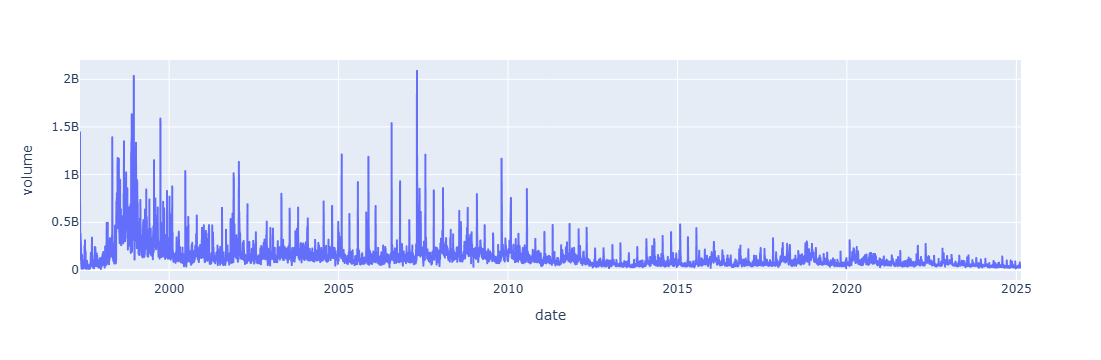

In [25]:
px.line(df, x= df.index, y = 'volume')

In [26]:
corr_matrix = df[['open', 'high', 'low', 'close', 'volume']].corr()

corr_matrix

,open,high,low,close,volume
open,1.000000,0.999924,0.999909,0.999813,-0.311725
high,0.999924,1.000000,0.999893,0.999914,-0.310808
low,0.999909,0.999893,1.000000,0.999918,-0.312712
close,0.999813,0.999914,0.999918,1.000000,-0.311741
volume,-0.311725,-0.310808,-0.312712,-0.311741,1.000000


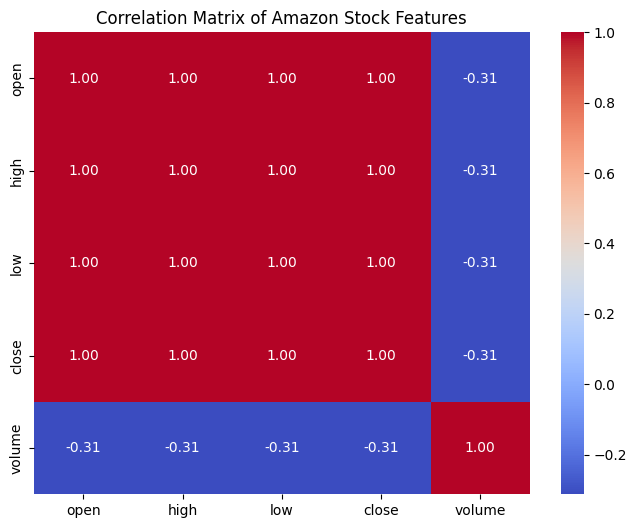

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix of Amazon Stock Features")
plt.show()

In [28]:
df[['daily_return', 'volume']].corr()

,daily_return,volume
daily_return,1.000000,0.159953
volume,0.159953,1.000000


In [29]:
df.head()

,open,high,low,close,adj_close,volume,daily_return,rolling_volatility
date,,,,,,,,
1997-05-15 04:00:00+00:00,0.121875,0.125000,0.096354,0.097917,0.097917,1443120000,NaN,NaN
1997-05-16 04:00:00+00:00,0.098438,0.098958,0.085417,0.086458,0.086458,294000000,-0.117028,NaN
1997-05-19 04:00:00+00:00,0.088021,0.088542,0.081250,0.085417,0.085417,122136000,-0.012040,NaN
1997-05-20 04:00:00+00:00,0.086458,0.087500,0.081771,0.081771,0.081771,109344000,-0.042685,NaN
1997-05-21 04:00:00+00:00,0.081771,0.082292,0.068750,0.071354,0.071354,377064000,-0.127392,NaN


In [30]:
df['year'] = df.index.year

df[['close', 'year']].head()

,close,year
date,,
1997-05-15 04:00:00+00:00,0.097917,1997
1997-05-16 04:00:00+00:00,0.086458,1997
1997-05-19 04:00:00+00:00,0.085417,1997
1997-05-20 04:00:00+00:00,0.081771,1997
1997-05-21 04:00:00+00:00,0.071354,1997


In [31]:
yearly_avg = df.groupby('year')['close'].mean()

yearly_avg

year
1997      0.156320
1998      0.783056
1999      3.453116
2000      2.326683
2001      0.610021
2002      0.824206
2003      1.887069
2004      2.178262
2005      1.994855
2006      1.795466
2007      3.361474
2008      3.494002
2009      4.364091
2010      6.957020
2011      9.833601
2012     11.015182
2013     14.901579
2014     16.627552
2015     23.906915
2016     34.976157
2017     48.408351
2018     82.086309
2019     89.459460
2020    134.042755
2021    167.193349
2022    126.098819
2023    121.372800
2024    184.628691
2025    229.514848
Name: close, dtype: float64

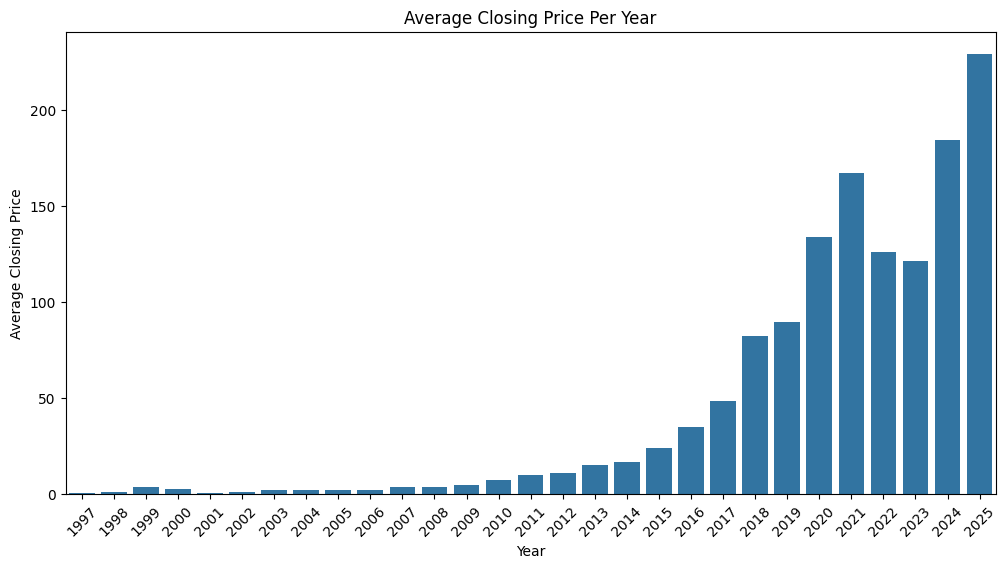

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(x=yearly_avg.index, y=yearly_avg.values)

plt.title("Average Closing Price Per Year")
plt.xlabel("Year")
plt.ylabel("Average Closing Price")
plt.xticks(rotation=45)
plt.show()

In [33]:
yearly_close = df.groupby('year')['close'].last()

yearly_return = yearly_close.pct_change() * 100

yearly_return

year
1997           NaN
1998    966.388463
1999     42.179009
2000    -79.556651
2001    -30.473893
2002     74.584106
2003    178.560081
2004    -15.830486
2005      6.457445
2006    -16.309651
2007    134.769379
2008    -44.645943
2009    162.324498
2010     33.809102
2011     -3.833336
2012     44.927791
2013     58.962817
2014    -22.177089
2015    117.783139
2016     10.945572
2017     55.956365
2018     28.431690
2019     23.027750
2020     76.256061
2021      2.376777
2022    -49.615215
2023     80.880955
2024     44.392521
2025      1.590777
Name: close, dtype: float64

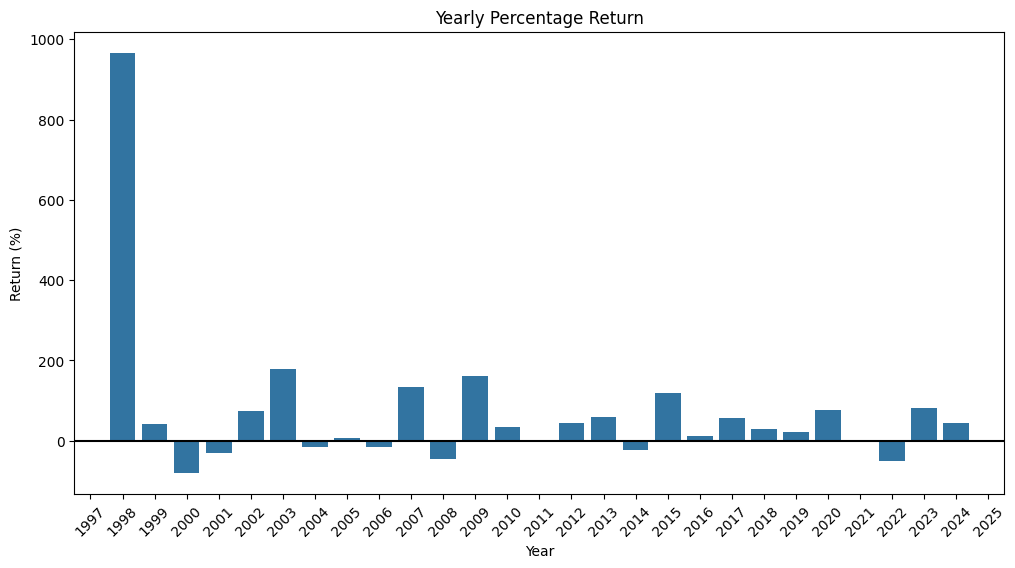

In [34]:
plt.figure(figsize=(12,6))

sns.barplot(x=yearly_return.index, y=yearly_return.values)

plt.title("Yearly Percentage Return")
plt.xlabel("Year")
plt.ylabel("Return (%)")
plt.xticks(rotation=45)
plt.axhline(0, color='black')
plt.show()

In [35]:
%run dashboard.py

!python dashboard.py

http://127.0.0.1:8050